In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import numpy as np
import tensorflow as tf
import pickle
import matplotlib.pyplot as plt


In [3]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

In [4]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [5]:
SAVE_DIR = '/content/MyDrive/Colab_Notebooks/nutshell'
import os
os.makedirs(SAVE_DIR, exist_ok = True)

In [6]:
with open('/content/drive/MyDrive/shakespeare_complete_works.txt', 'r', encoding='utf-8') as file:
  text = file.read().lower()
vocab_size = 15000
tokenizer = Tokenizer(num_words = vocab_size, oov_token="<oov")
tokenizer.fit_on_texts([text])

with open(f'{SAVE_DIR}/tokenizer.pkl', 'wb') as f:
  pickle.dump(tokenizer, f)


In [7]:
# the actual sliding window

full_sequence = tokenizer.texts_to_sequences([text])[0]

window_size = 30
input_sequence = []

for i in range(len(full_sequence) - window_size):
  input_sequence.append(full_sequence[i : i + window_size + 1])
input_sequences = np.array(input_sequence)

X = input_sequences[:, :-1]
y = input_sequences[:, -1] # sparse integers cus memory efficient

print(f"Total sequences: {len(X):,}")

Total sequences: 862,508


In [8]:
val_fraction = 0.1
split_index = int(len(X) * (1- val_fraction))

# shuffle before split
rng = np.random.default_rng(SEED)
shuffled_index = rng.permutation(len(X))
train_index, val_index = shuffled_index[:split_index], shuffled_index[split_index:]



In [9]:
X_train, y_train = X[train_index], y[train_index]
X_val, y_val = X[val_index], y[val_index]

print(f"Train: {len(X_train):,} | Val: {len(X_val):,}")

Train: 776,257 | Val: 86,251


In [23]:
from tensorflow.keras.layers import Input

model = Sequential([
    Input(shape=(window_size,)),
    Embedding(input_dim=vocab_size, output_dim=100),
    LSTM(150, return_sequences=True, dropout=0.2),
    LSTM(150, dropout = 0.2),
    Dense(vocab_size, activation='softmax')
])

model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics = ['accuracy'])
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ (None, 30, 100)        │     1,500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 30, 150)        │       150,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 150)            │       180,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15000)          │     2,265,000 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,096,200 (15.63 MB)

 Trainable params: 4,096,200 (15.63 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience = 10, restore_best_weights=True),
    ModelCheckpoint(filepath=f'{SAVE_DIR}/best_model.keras', monitor='val_loss', save_best_only = True)
]

history = model.fit(
    X_train, y_train,
    validation_data = (X_val, y_val),
    epochs = 25,
    batch_size = 512,
    callbacks = callbacks
)


Epoch 1/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 58s 37ms/step - accuracy: 0.0405 - loss: 6.7544 - val_accuracy: 0.0586 - val_loss: 6.4418
Epoch 2/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 58s 38ms/step - accuracy: 0.0714 - loss: 6.2972 - val_accuracy: 0.0828 - val_loss: 6.1927
Epoch 3/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 59s 39ms/step - accuracy: 0.0884 - loss: 6.0705 - val_accuracy: 0.0923 - val_loss: 6.0578
Epoch 4/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.0965 - loss: 5.9171 - val_accuracy: 0.0985 - val_loss: 5.9746
Epoch 5/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.1021 - loss: 5.7991 - val_accuracy: 0.1030 - val_loss: 5.9270
Epoch 6/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.1061 - loss: 5.7028 - val_accuracy: 0.1060 - val_loss: 5.8984
Epoch 7/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.1097 - loss: 5.6201 - val_accuracy: 0.1081 - val_loss: 5.8876
Epoch 8/25
1517/1517 ━━━━━━━━━━━━━━━━━━━━ 57s 38ms/step - accuracy: 0.1124 -

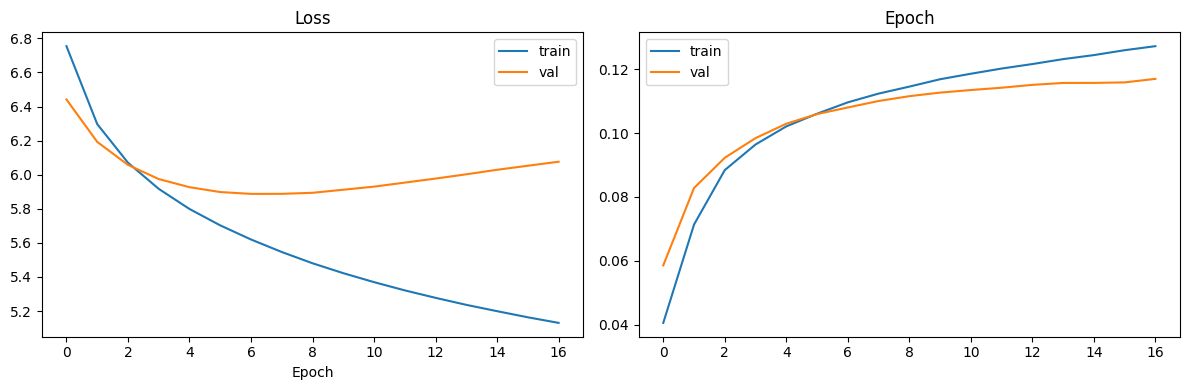

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'], label = 'train')
axes[0].plot(history.history['val_loss'], label = 'val')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label = 'train')
axes[1].plot(history.history['val_accuracy'], label = 'val')
axes[1].set_title('Accuracy')
axes[1].set_title('Epoch')
axes[1].legend()

plt.tight_layout()
plt.savefig(f'{SAVE_DIR}/training_curves.png', dpi = 150)
plt.show()

In [26]:
model.save(f'{SAVE_DIR}/final_model.keras')
print(f"Model and tokenizer saved to {SAVE_DIR}")

Model and tokenizer saved to /content/MyDrive/Colab_Notebooks/nutshell


In [27]:
# temperature sampling
def sample_with_temperature(predictions, temperature = 1.0):
  # high temp leads to creative and lower temp leads to accurate
  predictions = np.asarray(predictions).astype('float64')

  predictions[0] = 0.0 # padding token
  predictions[1] = 0.0 # <oov>

  predictions = np.log(predictions + 1e-7) / temperature
  exp_preds = np.exp(predictions)
  predictions = exp_preds / np.sum(exp_preds)
  probas = np.random.multinomial(1, predictions, 1)
  return np.argmax(probas)



In [28]:
def generate_text(seed_text, next_words, temperature = 1.0):
  for _ in range(next_words):
    token_list = tokenizer.texts_to_sequences([seed_text])[0]
    token_list = pad_sequences([token_list], maxlen = window_size, padding = 'pre')

    predicted_prob = model.predict(token_list, verbose = 0)[0]
    predicted_index = sample_with_temperature(predicted_prob, temperature)

    output_word = tokenizer.index_word.get(predicted_index, "")
    seed_text += " " + output_word

  return seed_text


In [31]:
print(generate_text("To be or not to , that is the question", 30, temperature = 0.3))

To be or not to , that is the question of this same and we have been a little crown and so much as the king of france and in the king of france and then that i have heard
